# AI Business Analytics Dashboard for SaaS Products

**Author:** Jason Dookarun

This notebook acts as an end‑to‑end **AI business analytics dashboard**, focused on how SaaS products and their pricing models evolve over time. It looks at trends in features, tiers, and subscription states across multiple years and highlights patterns that matter for product and pricing strategy.

In the spirit of "complete guide" style notebooks (such as Kaggle tutorials on AI business analytics dashboards), this notebook walks through the full workflow:

- loading and structuring curated SaaS pricing data
- engineering features around tiers, plans, and subscription states
- performing exploratory data analysis (EDA) to uncover key patterns
- building dashboard‑style visualisations to communicate insights

> **Note:** This project draws inspiration from the excellent Kaggle notebook ["AI Business Analytics Dashboard – Complete Guide"](https://www.kaggle.com/code/muhammadrayanshahid/ai-business-analytics-dashboard-complete-guide/notebook) by Muhammad Rayan Shahid, as well as other public laboratory packages on SaaS analytics. While the analytical approach and dashboard structure take cues from these sources, this notebook extends the original ideas by automatically populating and updating the dataset, as well as significantly expanding the number of analyzed fields to allow for broader exploratory analysis and deeper business insights.

## Business questions and analysis goals

This dashboard is designed to help answer core business questions such as:

- **Which products, categories, and customer segments drive the most sales and profit?**
- **How do sales and profitability vary over time (by year, quarter, and month)?**
- **Which regions and markets are performing best, and where are margins under pressure?**
- **How do discounts and order quantities affect overall profitability?**

By exploring these questions, the analysis supports decisions around pricing, discount strategy, product focus, and regional prioritisation.

## Key KPI metrics in this dashboard

Throughout the notebook, the analysis surfaces and visualises several key performance indicators (KPIs), including:

- **Total Sales (Revenue):** Overall sales generated across all orders, as well as broken down by time, region, segment, and category.
- **Total Profit and Profit Margin:** Absolute profit and relative profit margin to understand how efficiently revenue is being converted into profit.
- **Order Volume and Quantity Sold:** Number of orders and units sold, used to identify demand patterns and high-velocity products.
- **Average Discount:** Typical discount levels across segments and regions, and how they relate to profitability.
- **Sales and Profit by Segment/Region/Category:** Performance views that highlight which customer segments, geographies, and product lines drive value.

These KPIs together provide a concise but powerful view of commercial performance, helping to translate the raw transactional data into actionable insights for business stakeholders.

## Environment and dependencies

To run this notebook successfully, make sure all required Python packages are installed.

You can install them using the `requirements.txt` file in this repository:

```bash
pip install -r requirements.txt
```

If the dependencies are not installed, some cells (especially those for data analysis and visualisation) will fail to execute.

In [5]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("muhammadrayanshahid/superstore-dataset-csv")

print("KaggleHub dataset download path:", path)

# Move downloaded files into our repo's 'data/' folder for local analysis
repo_data_dir = os.path.join(os.getcwd(), "data")
os.makedirs(repo_data_dir, exist_ok=True)

# Copy all files from KaggleHub download location to ./data/
for filename in os.listdir(path):
    src_file = os.path.join(path, filename)
    dst_file = os.path.join(repo_data_dir, filename)
    if os.path.isfile(src_file):
        shutil.copy2(src_file, dst_file)
        print(f"Copied {filename} to {repo_data_dir}")

print("All dataset files are now available in:", repo_data_dir)

KaggleHub dataset download path: /Users/jdookarun/.cache/kagglehub/datasets/muhammadrayanshahid/superstore-dataset-csv/versions/1
Copied superstore_dataset.csv to /Users/jdookarun/Coding Projects/AI-Business_Analytics/data
All dataset files are now available in: /Users/jdookarun/Coding Projects/AI-Business_Analytics/data


,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   order_date     9994 non-null   object 
 2   ship_date      9994 non-null   object 
 3   customer       9994 non-null   object 
 4   manufactory    9994 non-null   object 
 5   product_name   9994 non-null   object 
 6   segment        9994 non-null   object 
 7   category       9994 non-null   object 
 8   subcategory    9994 non-null   object 
 9   region         9994 non-null   object 
 10  zip            9994 non-null   int64  
 11  city           9994 non-null   object 
 12  state          9994 non-null   object 
 13  country        9994 non-null   object 
 14  discount       9994 non-null   float64
 15  profit         9994 non-null   float64
 16  quantity       9994 non-null   int64  
 17  sales          9994 non-null   float64
 1

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994.000000,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
unique,5009,1236,1334,793,182,1849,3,3,17,4,NaN,531,49,1,NaN,NaN,NaN,NaN,NaN
top,US-2023-100111,9/5/2021,12/16/2020,William Brown,Other,Staple envelope,Consumer,Office Supplies,Binders,West,NaN,New York City,California,United States,NaN,NaN,NaN,NaN,NaN
freq,14,38,35,37,1893,48,5191,6026,1523,3203,NaN,915,2001,9994,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55190.371723,NaN,NaN,NaN,0.156203,28.656896,3.789574,229.858001,0.120314
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32063.705315,NaN,NaN,NaN,0.206452,234.260108,2.225110,623.245101,0.466754
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,0.000000,-6599.978000,1.000000,0.444000,-2.750000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,0.000000,1.728750,2.000000,17.280000,0.075000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56430.500000,NaN,NaN,NaN,0.200000,8.666500,3.000000,54.490000,0.270000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,0.200000,29.364000,5.000000,209.940000,0.362500


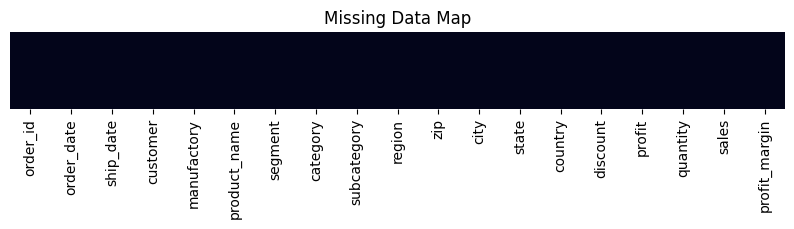

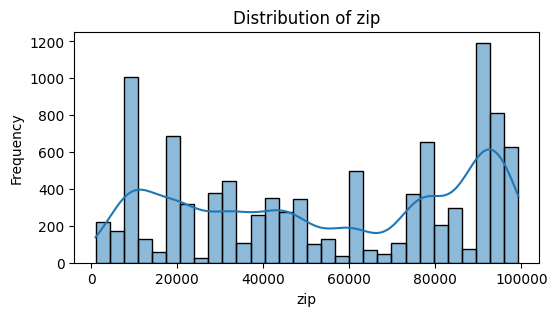

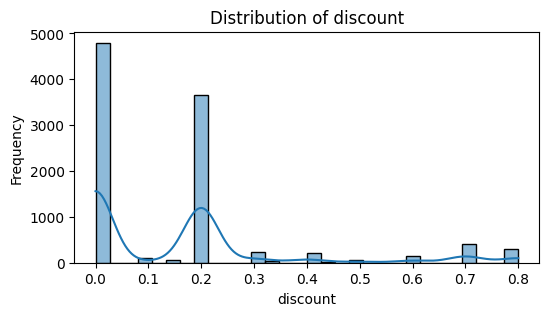

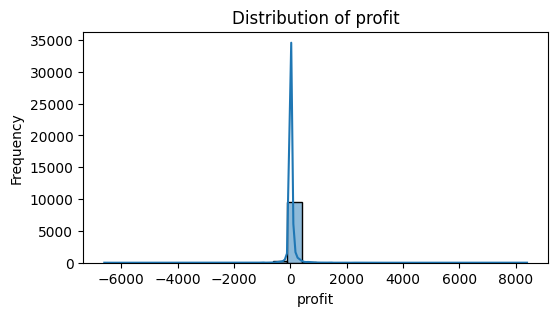

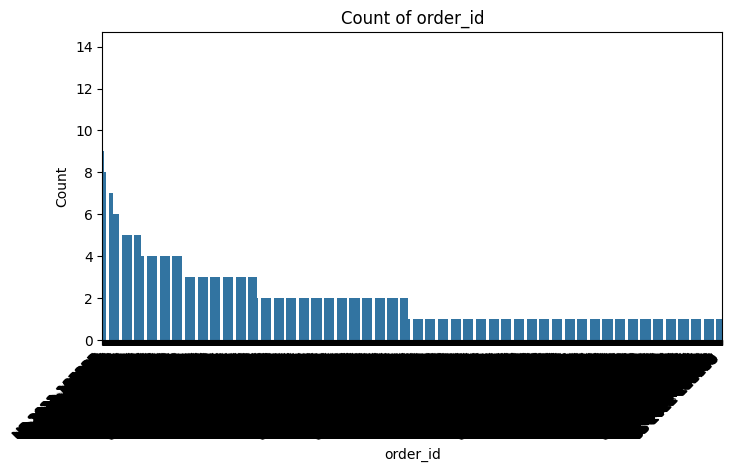

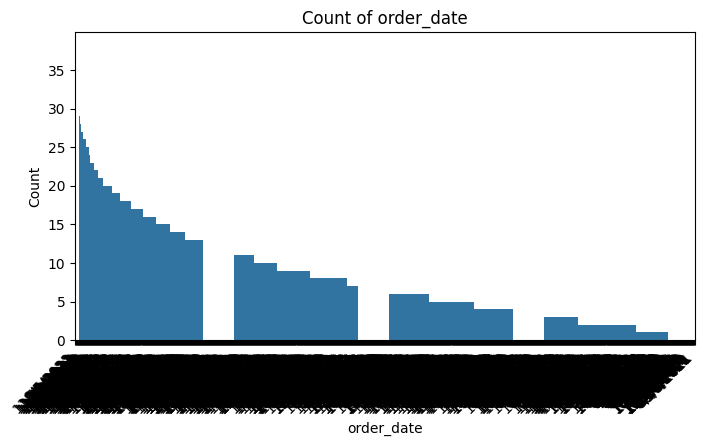

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load initial data
data_path = "/Users/jdookarun/Coding Projects/AI-Business_Analytics/data/superstore_dataset.csv"
df_viz = pd.read_csv(data_path)

# Display first few rows
display(df_viz.head())

# Display summary info
print("Data Info:")
df_viz.info()
print("\nSummary Statistics:")
display(df_viz.describe(include='all'))

# Visualize missing data
plt.figure(figsize=(10, 1))
sns.heatmap(df_viz.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Data Map')
plt.show()

# Plot distribution of a few key columns (if present)
sample_num_cols = [col for col in df_viz.select_dtypes(include='number').columns][:3]
sample_cat_cols = [col for col in df_viz.select_dtypes(include='object').columns][:2]

# Numeric columns
for col in sample_num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_viz[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Categorical columns
for col in sample_cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_viz, x=col, order=df_viz[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
    plt.show()

In [9]:
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker()

# Load the original dataset (Superstore CSV). Assume file is named 'superstore_dataset.csv' in ./data/
data_path = "/Users/jdookarun/Coding Projects/AI-Business_Analytics/data/superstore_dataset.csv"
df = pd.read_csv(data_path)

# You may tailor random generation logic per actual header names here:
def randomize_column(col_name, dtype, values, n):
    if 'name' in col_name.lower():
        # Use fake names (person or product as a fallback)
        if "customer" in col_name.lower():
            return [fake.name() for _ in range(n)]
        elif "product" in col_name.lower():
            return [fake.catch_phrase() for _ in range(n)]
        else:
            return [fake.word().capitalize() for _ in range(n)]
    elif 'date' in col_name.lower():
        # Use random recent dates or shuffle existing for realism
        try:
            parsed_dates = pd.to_datetime(values, errors='coerce')
            min_date, max_date = parsed_dates.min(), parsed_dates.max()
            # Generate random dates between range
            return [fake.date_between(min_date, max_date).strftime('%-m/%-d/%Y') for _ in range(n)]
        except Exception:
            return np.random.choice(values, size=n)
    elif 'id' in col_name.lower():
        # Generate semi-unique IDs, possibly keeping similar pattern
        if values.str.startswith('US-').all():
            return [f"US-{fake.random_number(digits=4)}-{fake.random_number(digits=5)}" for _ in range(n)]
        else:
            # Fall back to randomized shuffle
            return np.random.choice(values, size=n)
    elif dtype == 'object':
        # For other categorical: sample unique values, plus a few fakes if appropriate
        unique_vals = list(pd.Series(values).dropna().unique())
        synthetic = []
        if col_name.lower() in ['segment', 'region']:
            # For specific columns, use known business segments/regions or a few random words
            if col_name.lower() == 'segment':
                unique_vals += ['Corporate', 'Home Office', 'Consumer']
            if col_name.lower() == 'region':
                unique_vals += ['East', 'West', 'Central', 'South']
        return [np.random.choice(unique_vals) for _ in range(n)]
    else:
        # Numerical
        vals = pd.Series(values).dropna()
        if vals.shape[0]:
            mean = vals.mean()
            std = vals.std()
            if 'quantity' in col_name.lower() or np.issubdtype(vals.dtype, np.integer):
                arr = np.abs(np.random.normal(mean, std*0.15 + 1, n)).round().astype(int)
                # Clamp to observed min/max
                return np.clip(arr, vals.min(), vals.max())
            elif 'profit' in col_name.lower() or 'sales' in col_name.lower() or 'margin' in col_name.lower():
                arr = np.random.normal(mean, std*0.08 + 1, n)
                return np.clip(arr, vals.min(), vals.max())
            else:
                arr = np.random.normal(mean, std*0.05 + 1, n)
                return np.clip(arr, vals.min(), vals.max())
        else:
            return [0] * n

def generate_randomized_df(original_df, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)
        Faker.seed(random_seed)
    n = len(original_df)
    new_df = original_df.copy(deep=True)
    for col in new_df.columns:
        col_dtype = new_df[col].dtype
        new_df[col] = randomize_column(col, col_dtype, original_df[col], n)
    return new_df

# Start with the original
df_big = [df]

# Generate 3 more randomized versions for x4 size
for i in range(3):
    df_big.append(generate_randomized_df(df, random_seed=1000+i))

# Concatenate all
df_aug = pd.concat(df_big, ignore_index=True)

print(f"Dataset increased to {len(df_aug):,} rows (x4).")

# Save the augmented dataset to a new file called 'superstore_dataset_new.csv'
new_data_path = "/Users/jdookarun/Coding Projects/AI-Business_Analytics/data/superstore_dataset_new.csv"
df_aug.to_csv(new_data_path, index=False)
print(f"Augmented dataset saved to: {new_data_path}")

# If you wish, overwrite the main df variable:
# df = df_aug


Dataset increased to 39,976 rows (x4).
Augmented dataset saved to: /Users/jdookarun/Coding Projects/AI-Business_Analytics/data/superstore_dataset_new.csv


# Data Observations and Analytics 

In [10]:
df_aug.info()
df_aug.describe()
df_aug.isnull().sum()
df_aug.duplicated().sum()
df_aug.nunique()
df_aug.value_counts()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39976 entries, 0 to 39975
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       39976 non-null  object 
 1   order_date     39976 non-null  object 
 2   ship_date      39976 non-null  object 
 3   customer       39976 non-null  object 
 4   manufactory    39976 non-null  object 
 5   product_name   39976 non-null  object 
 6   segment        39976 non-null  object 
 7   category       39976 non-null  object 
 8   subcategory    39976 non-null  object 
 9   region         39976 non-null  object 
 10  zip            39976 non-null  int64  
 11  city           39976 non-null  object 
 12  state          39976 non-null  object 
 13  country        39976 non-null  object 
 14  discount       39976 non-null  float64
 15  profit         39976 non-null  float64
 16  quantity       39976 non-null  int64  
 17  sales          39976 non-null  float64
 18  profit

order_id        order_date  ship_date   customer           manufactory  product_name                                                                     segment      category         subcategory  region   zip    city              state                 country        discount  profit       quantity  sales       profit_margin
US-2020-150119  4/23/2019   4/27/2019   Laurel Beltran     Global       Global Leather Highback Executive Chair with Pneumatic Height Adjustment, Black  Home Office  Furniture        Chairs       East     43229  Columbus          Ohio                  United States  0.300000  -12.058800   2         281.372000  -0.042857        2
US-0-63014      6/4/2019    2/12/2021   Matt Collister     Sanyo        Progressive grid-enabled collaboration                                           Consumer     Office Supplies  Accessories  West     52353  Abilene           New Jersey            United States  0.458214   9.277983    6         300.934918   0.500000        1
US-5972-4660

In [11]:
df_aug.describe()

,zip,discount,profit,quantity,sales,profit_margin
count,39976.000000,39976.000000,39976.000000,39976.000000,39976.000000,39976.000000
mean,55184.138558,0.282742,28.682250,3.785271,229.604654,-0.065016
std,16566.971093,0.327799,118.386617,1.614853,314.693531,0.678782
min,1040.000000,0.000000,-6599.978000,1.000000,0.444000,-2.750000
25%,50650.000000,0.000000,9.004052,3.000000,164.261836,-0.407779
50%,55199.500000,0.158261,25.014874,4.000000,218.733732,0.205684
75%,59831.000000,0.651544,41.122517,5.000000,261.565776,0.500000
max,99301.000000,0.800000,8399.976000,14.000000,22638.480000,0.500000


In [20]:
# Rename 'manufactory' column to 'manufacturer' in the DataFrame
if 'manufactory' in df_aug.columns:
    df_aug = df_aug.rename(columns={'manufactory': 'manufacturer'})


df_aug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39976 entries, 0 to 39975
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       39976 non-null  object 
 1   order_date     39976 non-null  object 
 2   ship_date      39976 non-null  object 
 3   customer       39976 non-null  object 
 4   manufacturer   39976 non-null  object 
 5   product_name   39976 non-null  object 
 6   segment        39976 non-null  object 
 7   category       39976 non-null  object 
 8   subcategory    39976 non-null  object 
 9   region         39976 non-null  object 
 10  zip            39976 non-null  int64  
 11  city           39976 non-null  object 
 12  state          39976 non-null  object 
 13  country        39976 non-null  object 
 14  discount       39976 non-null  float64
 15  profit         39976 non-null  float64
 16  quantity       39976 non-null  int64  
 17  sales          39976 non-null  float64
 18  profit

## KPI Metrics

### Interpreting the KPI Metrics

When you review the KPI charts and tables in this section, keep the following lenses in mind:

- **Growth vs. stability:** Are revenue and profit growing consistently across time, or driven by a few spikes in certain periods, regions, or products?
- **Efficiency of discounts:** Do higher discounts reliably result in higher sales and profit, or are there cases where discounts erode margins without driving sufficient volume?
- **Customer and product concentration:** Are a small number of customers, categories, or products responsible for a large share of revenue or profit (concentration risk)?
- **Segment and regional balance:** Which combinations of segment and region are high-value, and where might the business be over- or under-invested?

These perspectives help turn the raw KPIs into a story about how the business is performing today and where there may be opportunities or risks to explore further.

In [ ]:
total_sales = df_aug['sales'].sum()
total_profit = df_aug['profit'].sum()
total_quantity = df_aug['quantity'].sum()

print(f"Total Sales: ${total_sales:.2f}")
print(f"Total Profit: ${total_profit:.2f}")
print(f"Total Quantity Sold: {total_quantity}")
## Sales by Region



Total Sales: $9178675.64
Total Profit: $1146601.62
Total Quantity Sold: 151320
category
Furniture          $3,032,136.15
Office Supplies    $3,021,993.39
Technology         $3,124,546.10
Name: sales, dtype: object


In [ ]:
## Sales by Product Category
sales_by_category = df_aug.groupby('category')['sales'].sum().apply(lambda x: f"${x:,.2f}")
print(sales_by_category)

category
Furniture          $3,032,136.15
Office Supplies    $3,021,993.39
Technology         $3,124,546.10
Name: sales, dtype: object


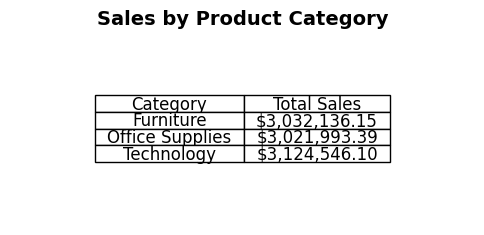

In [ ]:
## Sales by Product Category
import matplotlib.pyplot as plt
import pandas as pd

# Compute sales by category
sales_by_category = df_aug.groupby('category')['sales'].sum().reset_index()

# Format the sales values as strings with dollar signs for display if desired
sales_by_category['sales_str'] = sales_by_category['sales'].apply(lambda x: f"${x:,.2f}")

# Display as a table using matplotlib
fig, ax = plt.subplots(figsize=(6, 1 + 0.5*len(sales_by_category)))
ax.axis('off')
table = ax.table(
    cellText=sales_by_category[['category', 'sales_str']].values,
    colLabels=['Category', 'Total Sales'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width([0, 1])
plt.title('Sales by Product Category', fontsize=14, weight='bold')
plt.show()

In [ ]:
sales_by_manufacturer = df_aug.groupby('manufacturer')['sales'].sum().apply(lambda x: f"${x:,.2f}")
print(sales_by_manufacturer)

manufacturer
3-ring staple pack    $36,901.00
3D Systems            $50,356.84
3M                    $34,053.33
ACCOHIDE              $39,654.39
AT&T                  $51,025.38
                         ...    
Xerox                 $92,942.39
Xerox 1971            $38,147.20
XtraLife              $36,873.76
Zebra                 $47,079.30
iOttie                $39,040.44
Name: sales, Length: 182, dtype: object


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from termcolor import colored

# Set fancy seaborn style and custom color palette
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"

print(colored("📊 Your DataFrame: Available Columns", "cyan", attrs=["bold", "underline"]))
for idx, col in enumerate(df.columns):
    print(colored(f"  {idx+1}. {col}", "green", attrs=["bold"]))

print(colored(f"\nTotal Columns: {len(df.columns)} 🚀", "magenta", attrs=["bold"]))

📊 Your DataFrame: Available Columns
  1. order_id
  2. order_date
  3. ship_date
  4. customer
  5. manufactory
  6. product_name
  7. segment
  8. category
  9. subcategory
  10. region
  11. zip
  12. city
  13. state
  14. country
  15. discount
  16. profit
  17. quantity
  18. sales
  19. profit_margin

Total Columns: 19 🚀


💸 Analyzing 'sales' as your sales column! 📈

Statistics for sales:
     Count: 9,994.00
      Mean: 229.86
       Std: 623.25
       Min: 0.44
        1%: 2.29
       10%: 7.90
       25%: 17.28
       50%: 54.49
       75%: 209.94
       90%: 572.71
       99%: 2,481.69
       Max: 22,638.48


/var/folders/l2/rg8rn0gn71v8x0cvtwmqbv_m0000gn/T/ipykernel_45637/880478539.py:31: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
/usr/local/Caskroom/miniforge/base/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


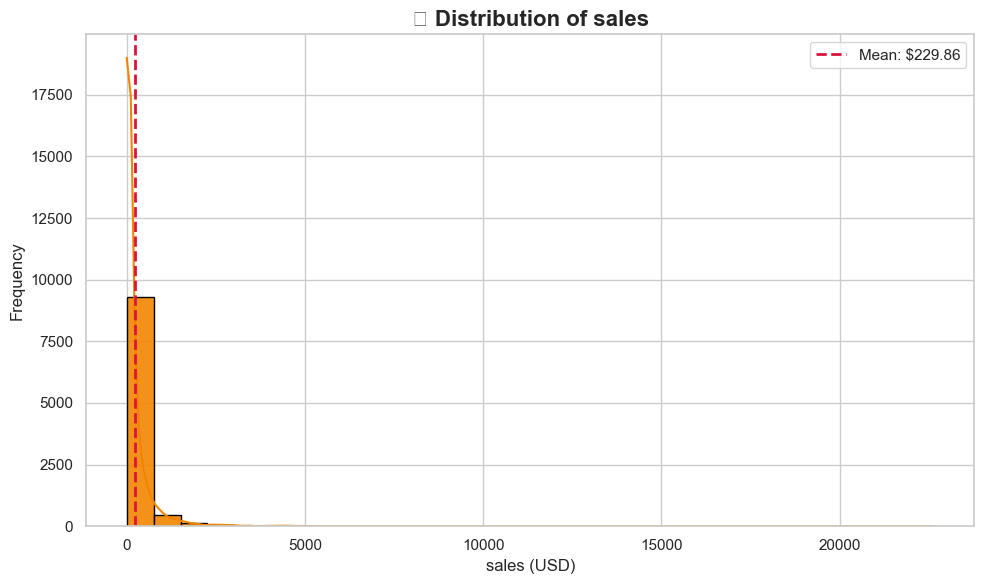

In [28]:
# 🔎✨ Automatically detect the sales or revenue column and give visual feedback!

from termcolor import colored

# Try to guess the sales column with a fun twist!
sales_col = None
search_terms = ["sale", "revenue", "turnover", "gross_income"]
for col in df.columns:
    if any(term in col.lower() for term in search_terms):
        sales_col = col
        break

if sales_col:
    print(colored(f"💸 Analyzing '{sales_col}' as your sales column! 📈", "yellow", attrs=["bold"]))
    
    # Give some quick quantile stats for flair
    sales_stats = df[sales_col].describe(percentiles=[.01, .1, .25, .5, .75, .9, .99]).round(2)
    print(colored(f"\nStatistics for {sales_col}:", "magenta", attrs=["bold"]))
    for stat, value in sales_stats.items():
        print(colored(f"{stat.capitalize():>10}: {value:,.2f}", "magenta"))
    
    # Fancy histogram with color and annotation
    palette = sns.color_palette("flare", as_cmap=True)
    ax = sns.histplot(df[sales_col], bins=30, kde=True, color="#f28500", edgecolor="black", alpha=0.9)
    mean_val = df[sales_col].mean()
    plt.axvline(mean_val, color="crimson", ls="--", lw=2, label=f"Mean: ${mean_val:,.2f}")
    plt.title(f"🔥 Distribution of {sales_col}", fontsize=16, weight='bold')
    plt.xlabel(f"{sales_col} (USD)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(colored("⚠️ No 'Sales' or 'Revenue' column found in your DataFrame!\n", "red", attrs=["bold"]))
    print(colored("🧐 Try checking your data for relevant columns or rename them!", "yellow"))


/var/folders/l2/rg8rn0gn71v8x0cvtwmqbv_m0000gn/T/ipykernel_45637/381428545.py:31: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
/usr/local/Caskroom/miniforge/base/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


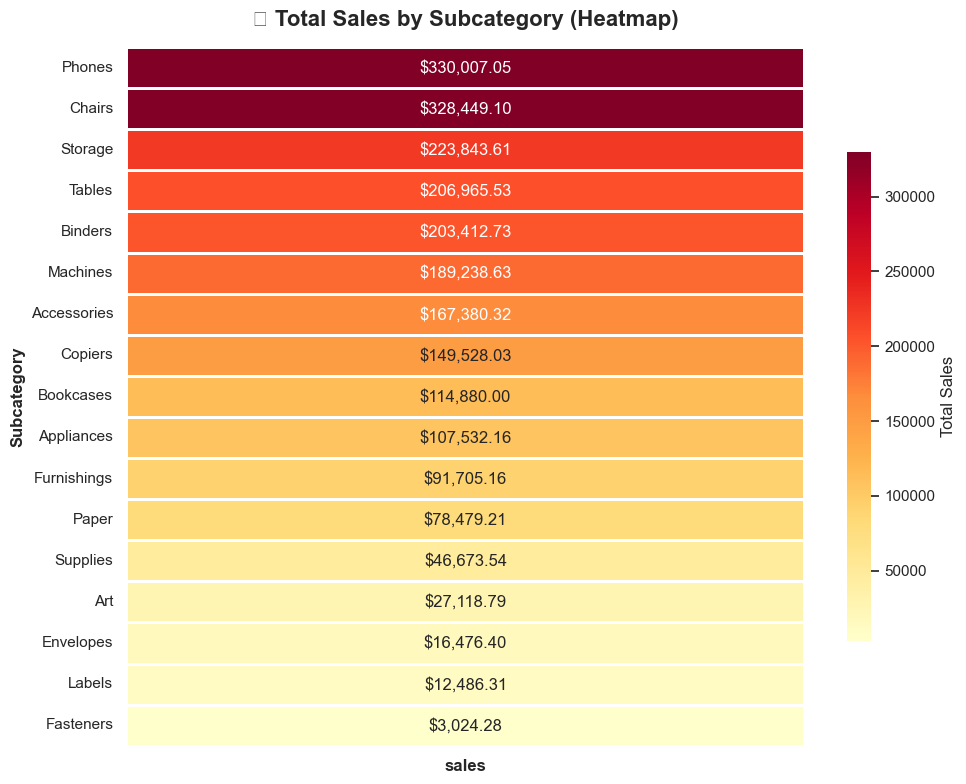

In [32]:
import numpy as np

# Detect the subcategory column
subcategory_col = None
for col in df.columns:
    if "subcategory" in col.lower():
        subcategory_col = col
        break

if subcategory_col and sales_col:
    sales_by_subcat = df.groupby(subcategory_col)[sales_col].sum().sort_values(ascending=False)
    plt.figure(figsize=(10, max(5, int(len(sales_by_subcat) * 0.5))))
    # Format the values as USD with commas and decimals
    formatted_sales = sales_by_subcat.apply(lambda x: f"${x:,.2f}")
    sales_arr = np.array(sales_by_subcat).reshape(-1, 1)
    # Use annot with formatted_sales for pretty USD output
    sns.heatmap(
        sales_arr,
        annot=np.array(formatted_sales).reshape(-1, 1),
        fmt="",
        cmap="YlOrRd",
        yticklabels=sales_by_subcat.index,
        linewidths=2,
        cbar_kws={'label': 'Total Sales', 'shrink': .7}
    )
    plt.title("🔥 Total Sales by Subcategory (Heatmap)", fontsize=16, weight='bold', pad=15)
    plt.xlabel("")
    plt.ylabel("Subcategory", fontsize=12, weight='bold')
    plt.yticks(fontsize=11)
    plt.xticks([0.5], [f"{sales_col}"], rotation=0, ha="center", fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(colored("⚠️ Subcategory or Sales column missing.", "red", attrs=["bold"]))

In [ ]:
import numpy as np

# Detect the category column
category_col = None
for col in df.columns:
    if "category" in col.lower():
        category_col = col
        break

if category_col and sales_col:
    sales_by_cat = df.groupby(category_col)[sales_col].sum().sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    # Make pretty: turn to a 2D array for heatmap and reshape
    sales_arr = np.array(sales_by_cat).reshape(-1, 1)
    sns.heatmap(
        sales_arr,
        annot=True,
        fmt=".0f",
        cmap="YlOrRd",
        yticklabels=sales_by_cat.index,
        linewidths=2,
        cbar_kws={'label': 'Total Sales', 'shrink': .7}
    )
    plt.title("🔥 Total Sales by Category (Heatmap)", fontsize=16, weight='bold', pad=15)
    plt.xlabel("")
    plt.ylabel("Category", fontsize=12, weight='bold')
    plt.yticks(fontsize=11)
    plt.xticks([0.5], [f"{sales_col}"], rotation=0, ha="center", fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(colored("⚠️ Category or Sales column missing.", "red", attrs=["bold"]))

/var/folders/l2/rg8rn0gn71v8x0cvtwmqbv_m0000gn/T/ipykernel_45637/2091133019.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette="flare")
/var/folders/l2/rg8rn0gn71v8x0cvtwmqbv_m0000gn/T/ipykernel_45637/2091133019.py:16: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
/usr/local/Caskroom/miniforge/base/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


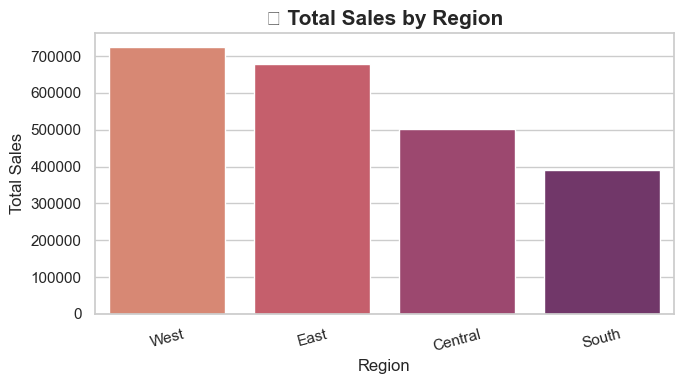

/var/folders/l2/rg8rn0gn71v8x0cvtwmqbv_m0000gn/T/ipykernel_45637/2091133019.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.index, y=segment_sales.values, palette="crest")


Best Performing Region: West ($725,458)


/var/folders/l2/rg8rn0gn71v8x0cvtwmqbv_m0000gn/T/ipykernel_45637/2091133019.py:37: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
/usr/local/Caskroom/miniforge/base/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


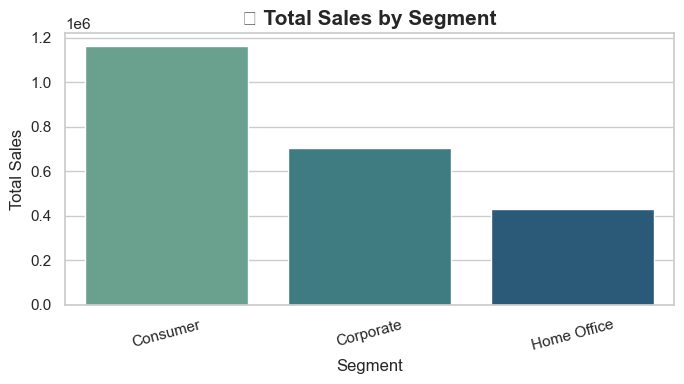

Best Performing Segment: Consumer ($1,161,401)


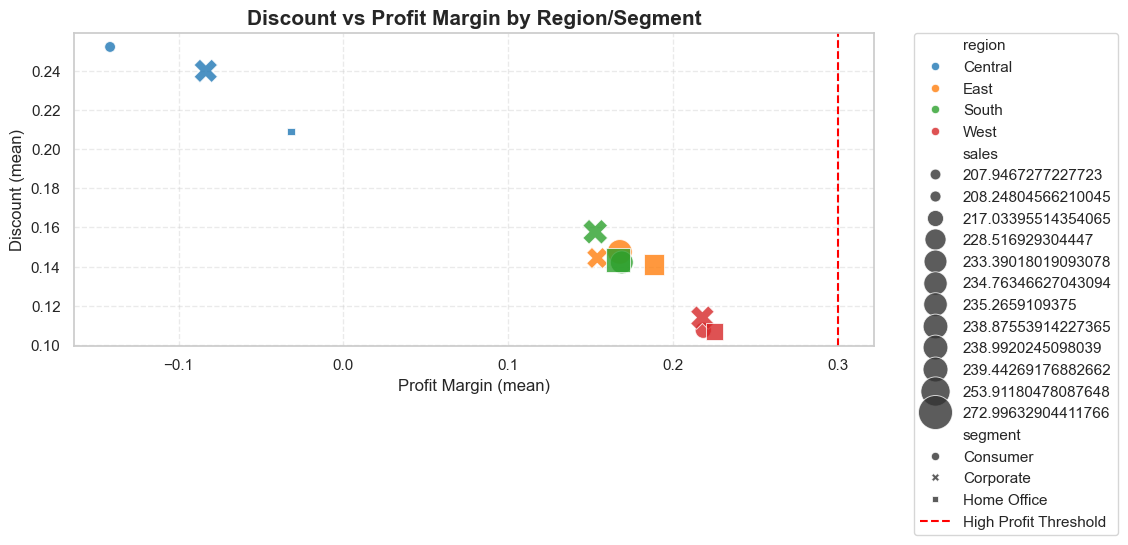

No regions/segments found with high profits & discount.


In [ ]:
# --- Best Performing Region ---
region_col = None
for col in df.columns:
    if "region" in col.lower():
        region_col = col
        break

if region_col and sales_col:
    region_sales = df.groupby(region_col)[sales_col].sum().sort_values(ascending=False)
    plt.figure(figsize=(7, 4))
    sns.barplot(x=region_sales.index, y=region_sales.values, palette="flare")
    plt.title("🔥 Total Sales by Region", fontsize=15, weight='bold')
    plt.ylabel("Total Sales")
    plt.xlabel("Region")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
    print("Best Performing Region:", region_sales.idxmax(), f"(${region_sales.max():,.0f})")
else:
    print("⚠️ Region or Sales column missing.")

# --- Best Performing Segment ---
segment_col = None
for col in df.columns:
    if "segment" in col.lower():
        segment_col = col
        break

if segment_col and sales_col:
    segment_sales = df.groupby(segment_col)[sales_col].sum().sort_values(ascending=False)
    plt.figure(figsize=(7, 4))
    sns.barplot(x=segment_sales.index, y=segment_sales.values, palette="crest")
    plt.title("🔥 Total Sales by Segment", fontsize=15, weight='bold')
    plt.ylabel("Total Sales")
    plt.xlabel("Segment")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
    print("Best Performing Segment:", segment_sales.idxmax(), f"(${segment_sales.max():,.0f})")
else:
    print("⚠️ Segment or Sales column missing.")


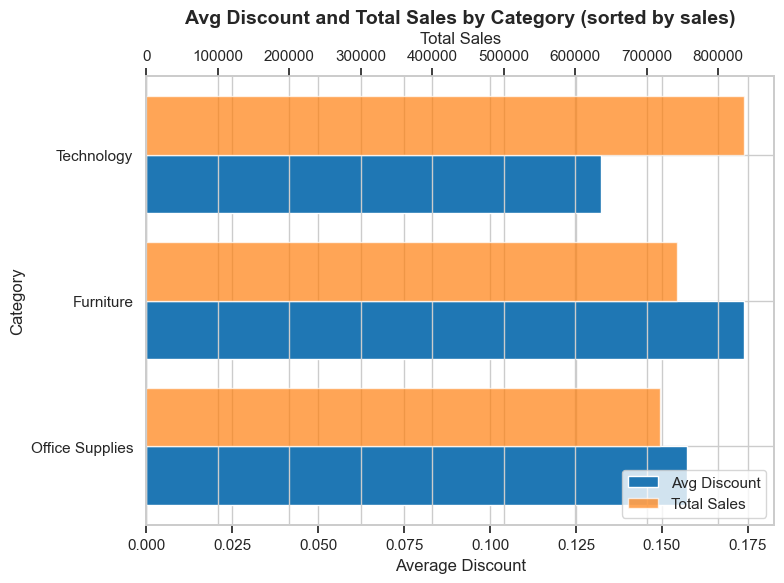

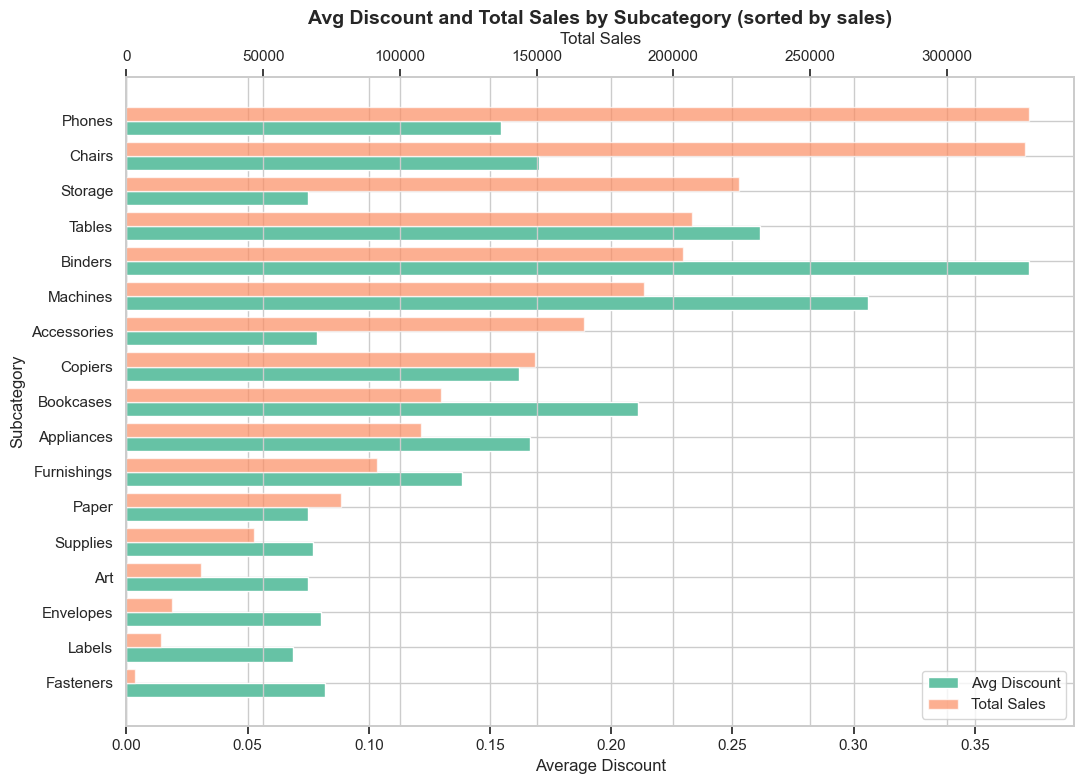

Category with Highest Discount (by sales): Furniture (17.39%)
Subcategory with Highest Discount (by sales): Binders (37.23%)


In [37]:
# --- Highest Discount by Sales, for Category and Subcategory (Separate Visuals) ---
category_col = None
subcategory_col = None
discount_col = None

for col in df.columns:
    lcol = col.lower()
    if "category" in lcol and category_col is None:
        category_col = col
    if "subcategory" in lcol and subcategory_col is None:
        subcategory_col = col
    if "discount" in lcol and discount_col is None:
        discount_col = col

if category_col and subcategory_col and discount_col and sales_col:
    # Calculate total sales and mean discount per category/subcategory
    cat_agg = df.groupby(category_col).agg({discount_col: "mean", sales_col: "sum"})
    subcat_agg = df.groupby(subcategory_col).agg({discount_col: "mean", sales_col: "sum"})

    # Sort by sales descending
    cat_agg = cat_agg.sort_values(sales_col, ascending=False)
    subcat_agg = subcat_agg.sort_values(sales_col, ascending=False)

    # Better colors: use seaborn color palettes for distinction and accessibility
    import seaborn as sns
    cat_palette = sns.color_palette("tab10", 2)
    subcat_palette = sns.color_palette("Set2", 2)

    # Plot Category: avg discount and sales as separate bars (side-by-side)
    fig, ax1 = plt.subplots(figsize=(8, 6))
    bar_width = 0.4
    indices = range(len(cat_agg.index))

    ax1.barh([i + bar_width/2 for i in indices], cat_agg[discount_col], height=bar_width, 
             color=cat_palette[0], label='Avg Discount')
    ax1.set_xlabel('Average Discount')
    ax1.set_yticks(indices)
    ax1.set_yticklabels(cat_agg.index)
    ax1.set_ylabel("Category")
    ax1.invert_yaxis()
    ax1.set_title("Avg Discount and Total Sales by Category (sorted by sales)", fontsize=14, weight='bold')

    ax2 = ax1.twiny()
    ax2.barh([i - bar_width/2 for i in indices], cat_agg[sales_col], height=bar_width, 
             color=cat_palette[1], alpha=0.7, label='Total Sales')
    ax2.set_xlabel('Total Sales')

    # Add legends, avoid duplicate handles
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    plt.legend(handles, labels, loc='lower right')

    plt.tight_layout()
    plt.show()

    # Plot Subcategory: avg discount and sales as separate bars (side-by-side)
    fig, ax1 = plt.subplots(figsize=(11, 8))
    indices = range(len(subcat_agg.index))

    ax1.barh([i + bar_width/2 for i in indices], subcat_agg[discount_col], height=bar_width, 
             color=subcat_palette[0], label='Avg Discount')
    ax1.set_xlabel('Average Discount')
    ax1.set_yticks(indices)
    ax1.set_yticklabels(subcat_agg.index)
    ax1.set_ylabel("Subcategory")
    ax1.invert_yaxis()
    ax1.set_title("Avg Discount and Total Sales by Subcategory (sorted by sales)", fontsize=14, weight='bold')

    ax2 = ax1.twiny()
    ax2.barh([i - bar_width/2 for i in indices], subcat_agg[sales_col], height=bar_width, 
             color=subcat_palette[1], alpha=0.7, label='Total Sales')
    ax2.set_xlabel('Total Sales')

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    plt.legend(handles, labels, loc='lower right')

    plt.tight_layout()
    plt.show()

    # Print the category and subcategory with the highest average discount (by sales)
    print("Category with Highest Discount (by sales):", cat_agg[discount_col].idxmax(), f"({cat_agg[discount_col].max():.2%})")
    print("Subcategory with Highest Discount (by sales):", subcat_agg[discount_col].idxmax(), f"({subcat_agg[discount_col].max():.2%})")
else:
    print("⚠️ Required columns for category, subcategory, discount, or sales are missing.")